In [2]:
!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo

# Fetch UCI Online Retail dataset
online_retail = fetch_ucirepo(id=352)

# Load the dataset
df = online_retail.data.features

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (541909, 6)

Columns:
['Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 Rows:


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
# Step 2: Data Quality Check

print("DATA TYPES")
print(df.dtypes)

print("\n" + "="*50)
print("MISSING VALUES")
print(df.isnull().sum())

print("\n" + "="*50)
print("DUPLICATE ROWS")
print("Duplicates:", df.duplicated().sum())

print("\n" + "="*50)
print("NEGATIVE QUANTITIES")
print("Negative Quantity:", (df["Quantity"] < 0).sum())

print("\n" + "="*50)
print("ZERO / NEGATIVE UNIT PRICE")
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

print("\n" + "="*50)
print("BASIC STATISTICS")
display(df[["Quantity", "UnitPrice"]].describe())

DATA TYPES
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

MISSING VALUES
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

DUPLICATE ROWS
Duplicates: 6007

NEGATIVE QUANTITIES
Negative Quantity: 10624

ZERO / NEGATIVE UNIT PRICE
UnitPrice <= 0: 2517

BASIC STATISTICS


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [5]:
# Step 3: Reload and Clean the Dataset

!pip install -q ucimlrepo

from ucimlrepo import fetch_ucirepo
import pandas as pd

# Reload UCI Online Retail dataset
online_retail = fetch_ucirepo(id=352)
df = online_retail.data.features

# Keep original row count
original_rows = len(df)

# Remove duplicate rows
df_clean = df.drop_duplicates().copy()

# Remove missing essential values
df_clean = df_clean.dropna(subset=["Description", "CustomerID"])

# Keep only valid sales transactions
df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
].copy()

# Convert InvoiceDate to datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Create Revenue
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

print("Original rows:", original_rows)
print("Cleaned rows:", len(df_clean))
print("Rows removed:", original_rows - len(df_clean))

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nCleaned dataset shape:", df_clean.shape)

print("\nFirst 5 cleaned rows:")
display(df_clean.head())

Original rows: 541909
Cleaned rows: 392617
Rows removed: 149292

Missing values after cleaning:
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

Cleaned dataset shape: (392617, 7)

First 5 cleaned rows:


,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [6]:
# Step 4: Feature Engineering for Date and Time

df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Day"] = df_clean["InvoiceDate"].dt.day
df_clean["Day_Name"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"] = df_clean["InvoiceDate"].dt.hour

print("New dataset shape:", df_clean.shape)

print("\nDate range:")
print("Start:", df_clean["InvoiceDate"].min())
print("End:", df_clean["InvoiceDate"].max())

print("\nYears:")
print(df_clean["Year"].value_counts().sort_index())

print("\nTop 10 hours by transaction count:")
print(df_clean["Hour"].value_counts().sort_index())

print("\nSample:")
display(
    df_clean[
        ["InvoiceDate", "Year", "Month", "Month_Name",
         "Day_Name", "Hour", "Revenue"]
    ].head()
)

New dataset shape: (392617, 13)

Date range:
Start: 2010-12-01 08:26:00
End: 2011-12-09 12:50:00

Years:
Year
2010     25662
2011    366955
Name: count, dtype: int64

Top 10 hours by transaction count:
Hour
6         1
7       379
8      8686
9     21926
10    37762
11    48363
12    70931
13    62991
14    53243
15    44782
16    23709
17    12940
18     2895
19     3231
20      778
Name: count, dtype: int64

Sample:


,InvoiceDate,Year,Month,Month_Name,Day_Name,Hour,Revenue
0,2010-12-01 08:26:00,2010,12,December,Wednesday,8,15.30
1,2010-12-01 08:26:00,2010,12,December,Wednesday,8,20.34
2,2010-12-01 08:26:00,2010,12,December,Wednesday,8,22.00
3,2010-12-01 08:26:00,2010,12,December,Wednesday,8,20.34
4,2010-12-01 08:26:00,2010,12,December,Wednesday,8,20.34


In [7]:
# Step 5: Overall Business Performance

total_revenue = df_clean["Revenue"].sum()
total_quantity = df_clean["Quantity"].sum()
unique_customers = df_clean["CustomerID"].nunique()
unique_products = df_clean["Description"].nunique()
unique_invoices = df_clean["InvoiceDate"].nunique()

# Calculate total unique invoices if InvoiceNo is available
print("TOTAL REVENUE: £{:,.2f}".format(total_revenue))
print("TOTAL QUANTITY SOLD:", f"{total_quantity:,}")
print("UNIQUE CUSTOMERS:", f"{unique_customers:,}")
print("UNIQUE PRODUCTS:", f"{unique_products:,}")
print("UNIQUE TRANSACTION TIMES:", f"{unique_invoices:,}")

# Average transaction revenue per row
average_transaction_value = df_clean["Revenue"].mean()

print("\nAVERAGE REVENUE PER LINE ITEM: £{:.2f}".format(
    average_transaction_value
))

# Top 10 countries by revenue
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 COUNTRIES BY REVENUE:")
display(country_revenue.to_frame("Revenue"))

TOTAL REVENUE: £8,885,586.15
TOTAL QUANTITY SOLD: 5,151,237
UNIQUE CUSTOMERS: 4,338
UNIQUE PRODUCTS: 3,877
UNIQUE TRANSACTION TIMES: 17,282

AVERAGE REVENUE PER LINE ITEM: £22.63

TOP 10 COUNTRIES BY REVENUE:


,Revenue
Country,
United Kingdom,7283438.304
Netherlands,285446.340
EIRE,265262.460
Germany,228660.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


In [8]:
# Step 6: Monthly Revenue Analysis

monthly_revenue = (
    df_clean
    .groupby(["Year", "Month", "Month_Name"])["Revenue"]
    .sum()
    .reset_index()
)

# Create a proper chronological date for sorting
monthly_revenue["Month_Date"] = pd.to_datetime(
    monthly_revenue["Year"].astype(str) + "-" +
    monthly_revenue["Month"].astype(str) + "-01"
)

monthly_revenue = monthly_revenue.sort_values("Month_Date")

print("MONTHLY REVENUE:")
display(
    monthly_revenue[
        ["Year", "Month_Name", "Revenue"]
    ]
)

# Highest and lowest revenue months
highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("\nHighest revenue month:")
print(
    highest_month["Month_Name"],
    int(highest_month["Year"]),
    "-> £{:,.2f}".format(highest_month["Revenue"])
)

print("\nLowest revenue month:")
print(
    lowest_month["Month_Name"],
    int(lowest_month["Year"]),
    "-> £{:,.2f}".format(lowest_month["Revenue"])
)

MONTHLY REVENUE:


,Year,Month_Name,Revenue
0,2010,December,570356.630
1,2011,January,568028.710
2,2011,February,446082.420
3,2011,March,594039.460
4,2011,April,468369.331
5,2011,May,677248.950
6,2011,June,660044.800
7,2011,July,598043.151
8,2011,August,644041.040
9,2011,September,950475.552



Highest revenue month:
November 2011 -> £1,156,148.36

Lowest revenue month:
February 2011 -> £446,082.42


In [9]:
# Step 7: Product Performance Analysis

product_revenue = (
    df_clean
    .groupby("Description")
    .agg(
        Revenue=("Revenue", "sum"),
        Quantity_Sold=("Quantity", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

print("TOP 10 PRODUCTS BY REVENUE:")
display(product_revenue.head(10))

print("\nTOP 10 PRODUCTS BY QUANTITY SOLD:")
display(
    product_revenue
    .sort_values("Quantity_Sold", ascending=False)
    .head(10)
)

print("\nHighest revenue product:")
print(
    product_revenue.index[0],
    "-> £{:,.2f}".format(product_revenue.iloc[0]["Revenue"])
)

TOP 10 PRODUCTS BY REVENUE:


,Revenue,Quantity_Sold
Description,,
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
REGENCY CAKESTAND 3 TIER,142264.75,12374
WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706
JUMBO BAG RED RETROSPOT,85040.54,46078
MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
POSTAGE,77785.96,3119
PARTY BUNTING,68785.23,15279
ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263
Manual,53419.93,6933



TOP 10 PRODUCTS BY QUANTITY SOLD:


,Revenue,Quantity_Sold
Description,,
"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,13558.41,54319
JUMBO BAG RED RETROSPOT,85040.54,46078
WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706
ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263
PACK OF 72 RETROSPOT CAKE CASES,16381.88,33670
POPCORN HOLDER,23414.11,30915
RABBIT NIGHT LIGHT,51251.24,27153



Highest revenue product:
PAPER CRAFT , LITTLE BIRDIE -> £168,469.60


In [10]:
# Step 8: Customer Revenue Analysis

customer_revenue = (
    df_clean
    .groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Purchase_Count=("Revenue", "count")
    )
    .sort_values("Total_Revenue", ascending=False)
)

print("TOP 10 CUSTOMERS BY REVENUE:")
display(customer_revenue.head(10))

print("\nTOP 10 CUSTOMERS BY QUANTITY PURCHASED:")
display(
    customer_revenue
    .sort_values("Total_Quantity", ascending=False)
    .head(10)
)

print("\nCustomer revenue statistics:")
display(customer_revenue["Total_Revenue"].describe())

TOP 10 CUSTOMERS BY REVENUE:


,Total_Revenue,Total_Quantity,Purchase_Count
CustomerID,,,
14646.0,280206.02,196915,2076
18102.0,258741.30,63924,430
17450.0,194390.79,69973,336
16446.0,168472.50,80997,3
14911.0,143711.17,80240,5670
12415.0,124914.53,77374,714
14156.0,117210.08,57768,1395
17511.0,91062.38,64549,963
16029.0,80673.24,40012,240



TOP 10 CUSTOMERS BY QUANTITY PURCHASED:


,Total_Revenue,Total_Quantity,Purchase_Count
CustomerID,,,
14646.0,280206.02,196915,2076
16446.0,168472.50,80997,3
14911.0,143711.17,80240,5670
12415.0,124914.53,77374,714
12346.0,77183.60,74215,1
17450.0,194390.79,69973,336
17511.0,91062.38,64549,963
18102.0,258741.30,63924,430
13694.0,65039.62,63312,568



Customer revenue statistics:


,Total_Revenue
count,4338.000000
mean,2048.314005
std,8978.764362
min,3.750000
25%,306.482500
50%,668.570000
75%,1660.597500
max,280206.020000


In [11]:
# Step 9: RFM Customer Analysis

# Reference date = day after the last transaction
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_clean
    .groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x:
                 (reference_date - x.max()).days),
        Frequency=("InvoiceDate", "count"),
        Monetary=("Revenue", "sum")
    )
)

print("RFM dataset shape:", rfm.shape)

print("\nRFM sample:")
display(rfm.head(10))

print("\nRFM statistics:")
display(rfm.describe())

print("\nBest recent customers:")
display(rfm.sort_values("Recency").head(10))

RFM dataset shape: (4338, 3)

RFM sample:


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40
12352.0,36,85,2506.04
12353.0,204,4,89.00
12354.0,232,58,1079.40
12355.0,214,13,459.40



RFM statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,90.506455,2048.314005
std,100.014169,225.470819,8978.764362
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,306.482500
50%,51.000000,41.000000,668.570000
75%,142.000000,98.000000,1660.597500
max,374.000000,7674.000000,280206.020000



Best recent customers:


,Recency,Frequency,Monetary
CustomerID,,,
17364.0,1,406,4462.68
12433.0,1,420,13375.87
13599.0,1,245,5129.12
13536.0,1,178,3444.39
16933.0,1,44,563.23
17581.0,1,439,11025.24
15898.0,1,84,1383.83
16892.0,1,97,518.19
17644.0,1,157,2895.64


In [12]:
# Step 10: RFM Customer Segmentation using K-Means

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select RFM features
rfm_features = rfm[["Recency", "Frequency", "Monetary"]]

# Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Create 4 customer segments
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("Customer segmentation completed.")
print("Number of customers:", len(rfm))

print("\nCustomers per cluster:")
print(rfm["Cluster"].value_counts().sort_index())

print("\nCluster characteristics:")
cluster_summary = (
    rfm.groupby("Cluster")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

display(cluster_summary)

Customer segmentation completed.
Number of customers: 4338

Customers per cluster:
Cluster
0    3247
1    1081
2       6
3       4
Name: count, dtype: int64

Cluster characteristics:


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3247,41.31,103.23,2085.66
1,1081,247.21,27.40,635.59
2,6,7.67,825.67,190655.87
3,4,2.00,5716.75,70611.62


In [13]:
# Step 11: Log-transform skewed RFM features

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

rfm_model = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Log transformation for highly skewed variables
rfm_model["Frequency"] = np.log1p(rfm_model["Frequency"])
rfm_model["Monetary"] = np.log1p(rfm_model["Monetary"])

# Standardize all RFM features
scaler_rfm = StandardScaler()
rfm_scaled = scaler_rfm.fit_transform(rfm_model)

# K-Means with 4 segments
kmeans_rfm = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Segment"] = kmeans_rfm.fit_predict(rfm_scaled)

# Summarize the new segments
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

print("CUSTOMERS PER SEGMENT:")
print(rfm["Segment"].value_counts().sort_index())

print("\nSEGMENT CHARACTERISTICS:")
display(segment_summary)

CUSTOMERS PER SEGMENT:
Segment
0    1586
1     878
2     946
3     928
Name: count, dtype: int64

SEGMENT CHARACTERISTICS:


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
0,1586,54.03,63.19,1055.39
1,878,265.16,21.34,458.95
2,946,26.43,274.15,6901.69
3,928,62.41,15.42,301.49


In [15]:
# Step 12: Final Customer Segments

segment_names = {
    0: "Regular Customers",
    1: "At-Risk Customers",
    2: "High-Value Loyal Customers",
    3: "Low-Value Customers"
}

# Assign readable names
rfm["Segment_Name"] = rfm["Segment"].map(segment_names)

# Create final segment report
segment_report = (
    rfm.groupby("Segment_Name")
    .agg(
        Customers=("Recency", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .sort_values("Total_Revenue", ascending=False)
    .round(2)
)

print("FINAL CUSTOMER SEGMENTS")
display(segment_report)

# Correct customer count
total_customers = rfm.index.nunique()

# Correct total revenue
total_customer_revenue = rfm["Monetary"].sum()

print("\nTotal customers:", total_customers)
print("Total customer revenue: £{:,.2f}".format(total_customer_revenue))

FINAL CUSTOMER SEGMENTS


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment_Name,,,,,
High-Value Loyal Customers,946,26.43,274.15,6901.69,6529001.05
Regular Customers,1586,54.03,63.19,1055.39,1673841.87
At-Risk Customers,878,265.16,21.34,458.95,402961.80
Low-Value Customers,928,62.41,15.42,301.49,279781.43



Total customers: 4338
Total customer revenue: £8,885,586.15


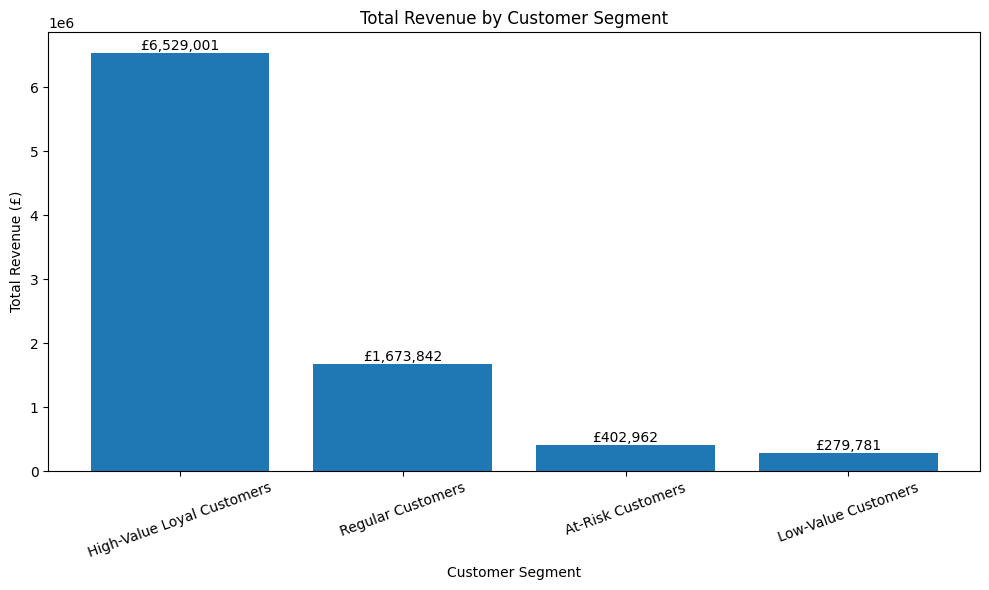

In [16]:
# Step 13: Customer Segment Revenue Visualization

import matplotlib.pyplot as plt

segment_revenue = (
    rfm.groupby("Segment_Name")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    segment_revenue.index,
    segment_revenue.values
)

plt.title("Total Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=20)

# Add revenue labels
for bar, value in zip(bars, segment_revenue.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"£{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "customer_segment_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

TOP 10 COUNTRIES BY REVENUE:


,Revenue
Country,
United Kingdom,7283438.30
Netherlands,285446.34
EIRE,265262.46
Germany,228660.40
France,208934.31
Australia,138453.81
Spain,61558.56
Switzerland,56443.95
Belgium,41196.34



Highest revenue country:
United Kingdom -> £7,283,438.30


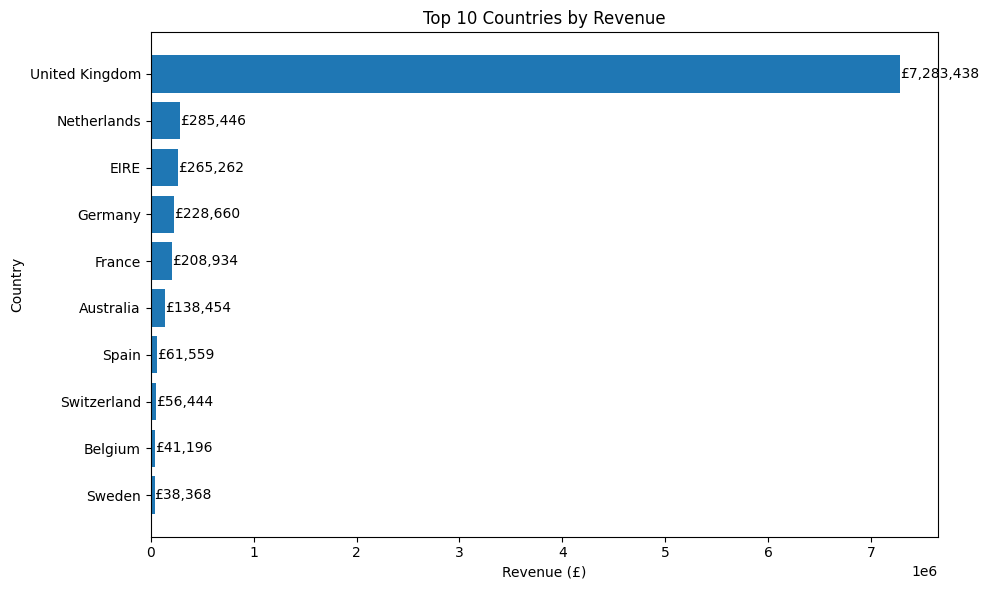

In [17]:
# Step 14: Country Revenue Analysis

country_revenue = (
    df_clean
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_10_countries = country_revenue.head(10)

print("TOP 10 COUNTRIES BY REVENUE:")
display(
    top_10_countries
    .to_frame("Revenue")
    .round(2)
)

print("\nHighest revenue country:")
print(
    top_10_countries.index[0],
    "-> £{:,.2f}".format(top_10_countries.iloc[0])
)

# Visualization
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_10_countries.index[::-1],
    top_10_countries.values[::-1]
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

for bar, value in zip(bars, top_10_countries.values[::-1]):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"£{value:,.0f}",
        va="center",
        ha="left"
    )

plt.tight_layout()

plt.savefig(
    "top_10_countries_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

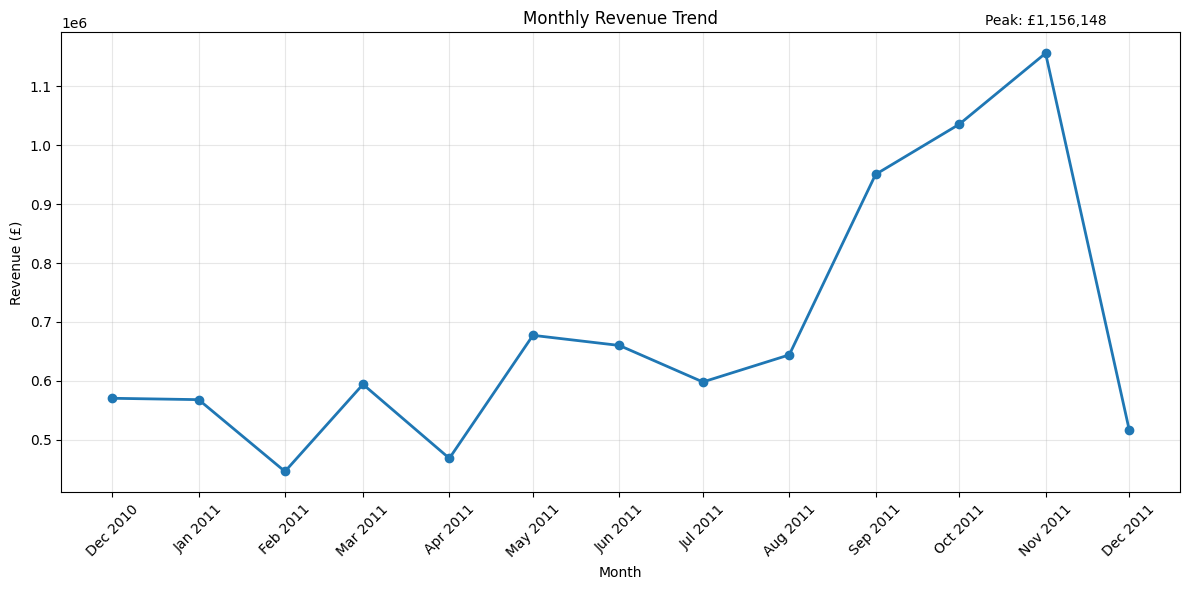

In [18]:
# Step 15: Monthly Revenue Trend Visualization

import matplotlib.pyplot as plt

# Use the monthly_revenue table created earlier
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["Month_Date"],
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(
    monthly_revenue["Month_Date"],
    monthly_revenue["Month_Date"].dt.strftime("%b %Y"),
    rotation=45
)

# Highlight the highest revenue month
max_idx = monthly_revenue["Revenue"].idxmax()
max_row = monthly_revenue.loc[max_idx]

plt.annotate(
    f"Peak: £{max_row['Revenue']:,.0f}",
    xy=(max_row["Month_Date"], max_row["Revenue"]),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

REVENUE BY DAY OF WEEK:


,Revenue
Day_Name,
Monday,1362471.55
Tuesday,1697717.00
Wednesday,1583987.24
Thursday,1972933.33
Friday,1483043.76
Saturday,NaN
Sunday,785433.27



Highest revenue day:
Thursday -> £1,972,933.33

Lowest revenue day:
Sunday -> £785,433.27


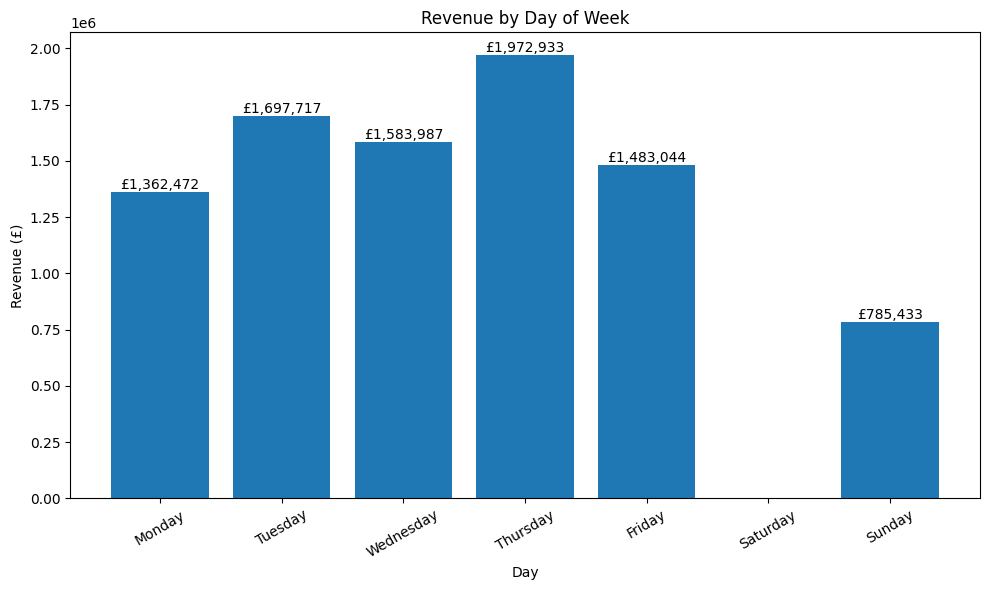

In [19]:
# Step 16: Revenue by Day of Week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_revenue = (
    df_clean
    .groupby("Day_Name")["Revenue"]
    .sum()
    .reindex(day_order)
)

print("REVENUE BY DAY OF WEEK:")
display(
    daily_revenue
    .to_frame("Revenue")
    .round(2)
)

print("\nHighest revenue day:")
print(
    daily_revenue.idxmax(),
    "-> £{:,.2f}".format(daily_revenue.max())
)

print("\nLowest revenue day:")
print(
    daily_revenue.idxmin(),
    "-> £{:,.2f}".format(daily_revenue.min())
)

# Visualization
plt.figure(figsize=(10, 6))

bars = plt.bar(
    daily_revenue.index,
    daily_revenue.values
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30)

for bar, value in zip(bars, daily_revenue.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"£{value:,.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "revenue_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

REVENUE BY HOUR:


,Revenue
Hour,
6,4.25
7,31059.21
8,281987.79
9,842371.54
10,1258183.04
11,1101150.80
12,1373668.59
13,1168435.96
14,991932.87



Highest revenue hour:
12 -> £1,373,668.59


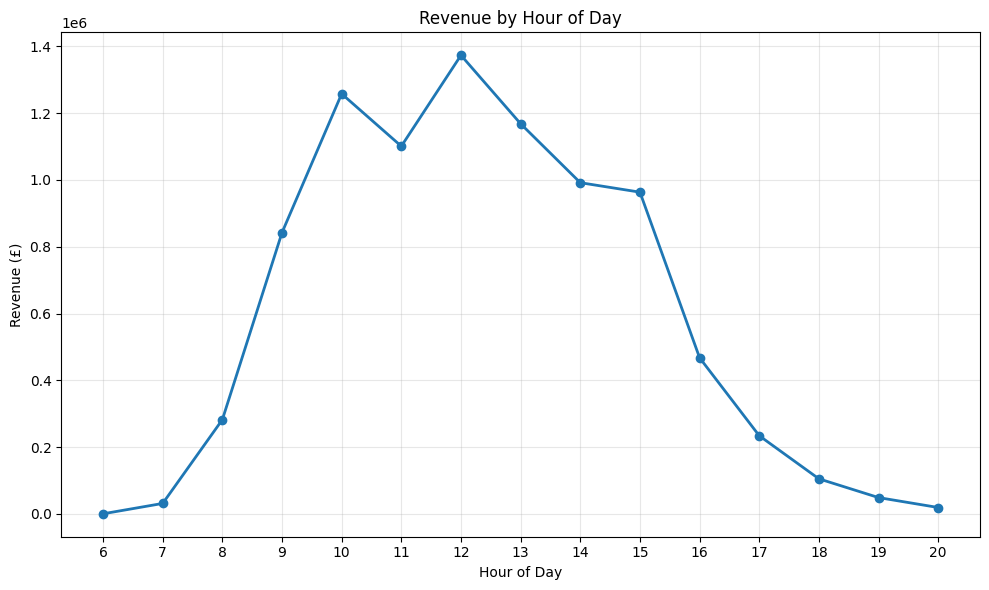

In [20]:
# Step 17: Revenue by Hour

hourly_revenue = (
    df_clean
    .groupby("Hour")["Revenue"]
    .sum()
    .sort_index()
)

print("REVENUE BY HOUR:")
display(
    hourly_revenue
    .to_frame("Revenue")
    .round(2)
)

print("\nHighest revenue hour:")
print(
    hourly_revenue.idxmax(),
    "-> £{:,.2f}".format(hourly_revenue.max())
)

# Visualization
plt.figure(figsize=(10, 6))

plt.plot(
    hourly_revenue.index,
    hourly_revenue.values,
    marker="o",
    linewidth=2
)

plt.title("Revenue by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue (£)")
plt.xticks(hourly_revenue.index)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "revenue_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

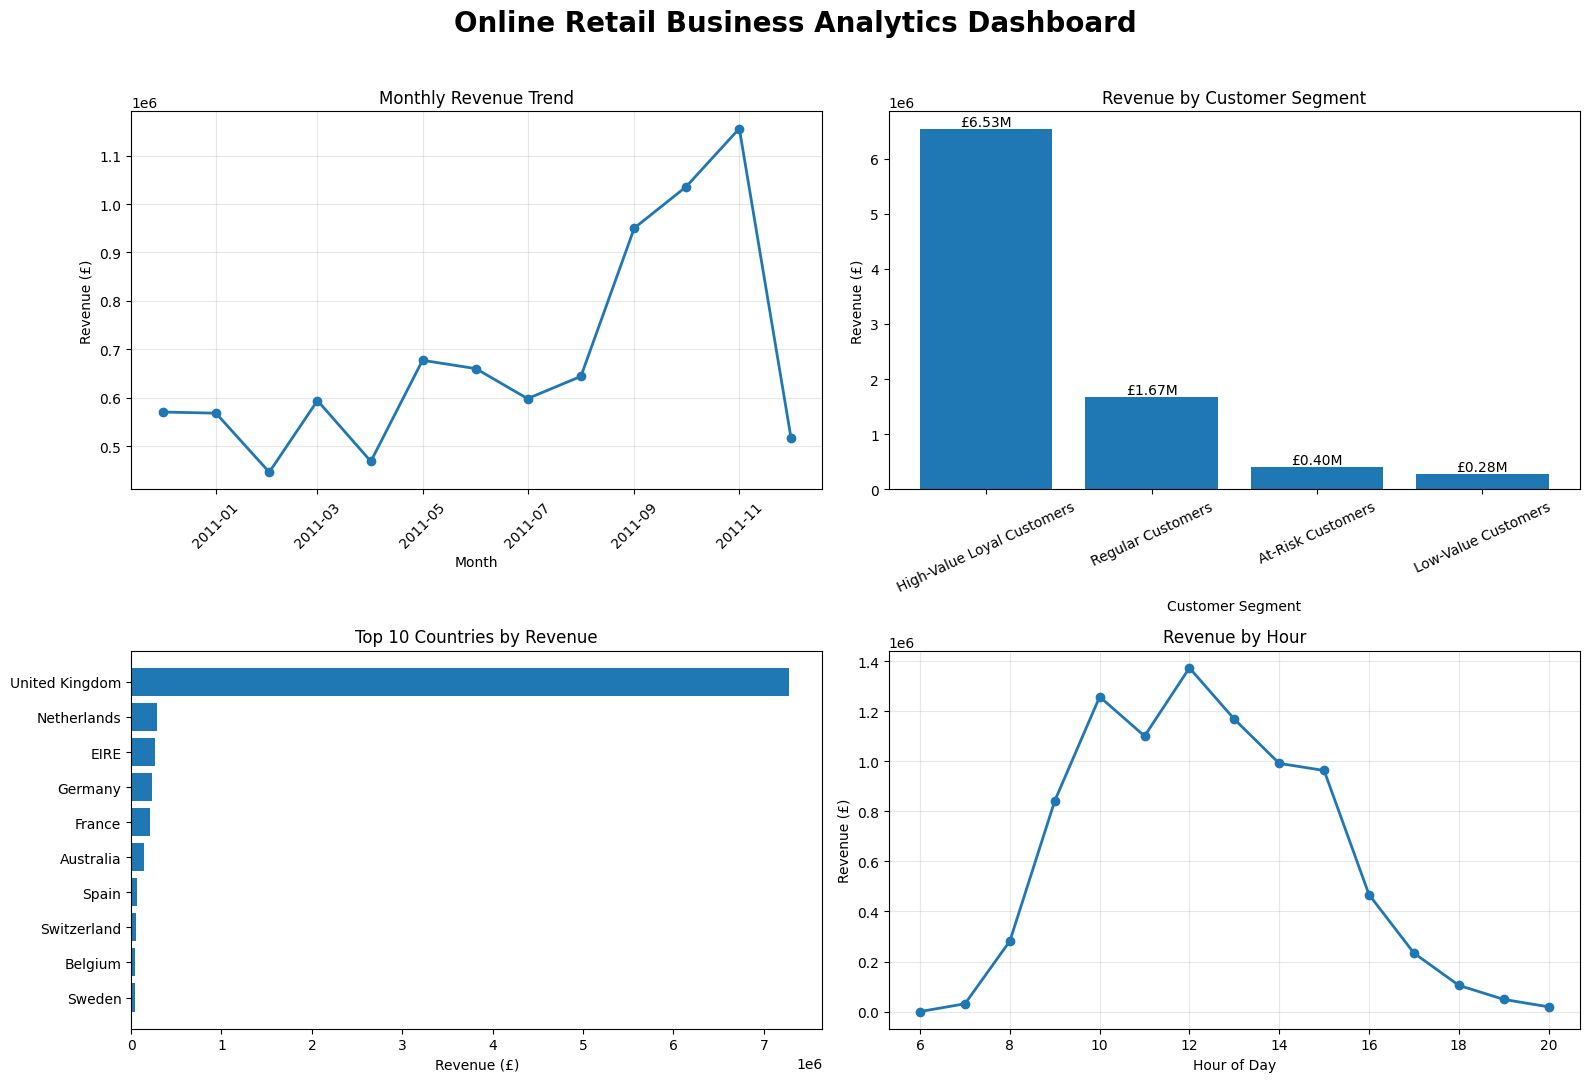

In [21]:
# Step 18: Create Final Retail Analytics Dashboard

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# -------------------------------------------------
# 1. Monthly Revenue Trend
# -------------------------------------------------
axes[0, 0].plot(
    monthly_revenue["Month_Date"],
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Revenue (£)")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# -------------------------------------------------
# 2. Customer Segment Revenue
# -------------------------------------------------
segment_revenue = (
    rfm.groupby("Segment_Name")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

bars = axes[0, 1].bar(
    segment_revenue.index,
    segment_revenue.values
)

axes[0, 1].set_title("Revenue by Customer Segment")
axes[0, 1].set_xlabel("Customer Segment")
axes[0, 1].set_ylabel("Revenue (£)")
axes[0, 1].tick_params(axis="x", rotation=25)

for bar, value in zip(bars, segment_revenue.values):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"£{value/1e6:.2f}M",
        ha="center",
        va="bottom"
    )

# -------------------------------------------------
# 3. Top 10 Countries
# -------------------------------------------------
top_10_countries = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

axes[1, 0].barh(
    top_10_countries.index[::-1],
    top_10_countries.values[::-1]
)

axes[1, 0].set_title("Top 10 Countries by Revenue")
axes[1, 0].set_xlabel("Revenue (£)")

# -------------------------------------------------
# 4. Revenue by Hour
# -------------------------------------------------
axes[1, 1].plot(
    hourly_revenue.index,
    hourly_revenue.values,
    marker="o",
    linewidth=2
)

axes[1, 1].set_title("Revenue by Hour")
axes[1, 1].set_xlabel("Hour of Day")
axes[1, 1].set_ylabel("Revenue (£)")
axes[1, 1].grid(True, alpha=0.3)

# -------------------------------------------------
# Dashboard title
# -------------------------------------------------
fig.suptitle(
    "Online Retail Business Analytics Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "thiranex_task_4_retail_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Step 19: Final Business Insights

print("=" * 70)
print("THIRANEX TASK 4 — FINAL BUSINESS INSIGHTS")
print("=" * 70)

print("\n1. OVERALL PERFORMANCE")
print(f"Total Revenue: £{df_clean['Revenue'].sum():,.2f}")
print(f"Total Quantity Sold: {df_clean['Quantity'].sum():,}")
print(f"Unique Customers: {df_clean['CustomerID'].nunique():,}")
print(f"Unique Products: {df_clean['Description'].nunique():,}")

print("\n2. MONTHLY PERFORMANCE")
print(
    f"Highest Revenue Month: "
    f"{highest_month['Month_Name']} {int(highest_month['Year'])} "
    f"→ £{highest_month['Revenue']:,.2f}"
)
print(
    f"Lowest Revenue Month: "
    f"{lowest_month['Month_Name']} {int(lowest_month['Year'])} "
    f"→ £{lowest_month['Revenue']:,.2f}"
)

print("\n3. PRODUCT PERFORMANCE")
print(
    f"Top Revenue Product: "
    f"{product_revenue.index[0]} "
    f"→ £{product_revenue.iloc[0]['Revenue']:,.2f}"
)

print("\n4. CUSTOMER SEGMENTATION")
for segment, row in segment_report.iterrows():
    print(
        f"{segment}: {int(row['Customers']):,} customers "
        f"→ £{row['Total_Revenue']:,.2f}"
    )

print("\n5. GEOGRAPHIC PERFORMANCE")
print(
    f"Top Revenue Country: "
    f"{country_revenue.index[0]} "
    f"→ £{country_revenue.iloc[0]:,.2f}"
)

print("\n6. TIME-BASED PERFORMANCE")
print(
    f"Highest Revenue Day: "
    f"{daily_revenue.idxmax()} "
    f"→ £{daily_revenue.max():,.2f}"
)
print(
    f"Highest Revenue Hour: "
    f"{hourly_revenue.idxmax()}:00 "
    f"→ £{hourly_revenue.max():,.2f}"
)

print("\n" + "=" * 70)
print("PROJECT CONCLUSION")
print("=" * 70)

print("""
The Online Retail dataset shows strong revenue concentration across
high-value customers and the United Kingdom market. Revenue increased
substantially toward the end of 2011, reaching its highest level in
November. RFM-based K-Means segmentation identified a High-Value Loyal
customer group that contributes the majority of total revenue.

The analysis also shows that revenue is strongest around midday,
particularly at 12:00, while Thursday records the highest revenue among
the days with transactions. These findings can support customer
retention, targeted marketing, inventory planning, and sales scheduling.
""")

THIRANEX TASK 4 — FINAL BUSINESS INSIGHTS

1. OVERALL PERFORMANCE
Total Revenue: £8,885,586.15
Total Quantity Sold: 5,151,237
Unique Customers: 4,338
Unique Products: 3,877

2. MONTHLY PERFORMANCE
Highest Revenue Month: November 2011 → £1,156,148.36
Lowest Revenue Month: February 2011 → £446,082.42

3. PRODUCT PERFORMANCE
Top Revenue Product: PAPER CRAFT , LITTLE BIRDIE → £168,469.60

4. CUSTOMER SEGMENTATION
High-Value Loyal Customers: 946 customers → £6,529,001.05
Regular Customers: 1,586 customers → £1,673,841.87
At-Risk Customers: 878 customers → £402,961.80
Low-Value Customers: 928 customers → £279,781.43

5. GEOGRAPHIC PERFORMANCE
Top Revenue Country: United Kingdom → £7,283,438.30

6. TIME-BASED PERFORMANCE
Highest Revenue Day: Thursday → £1,972,933.33
Highest Revenue Hour: 12:00 → £1,373,668.59

PROJECT CONCLUSION

The Online Retail dataset shows strong revenue concentration across
high-value customers and the United Kingdom market. Revenue increased
substantially toward the en

In [23]:
# Step 20: Create README.md

readme_content = """
# Thiranex Task 4 — Real-World Retail Data Analytics

## Project Overview

This project analyzes a real-world online retail dataset to uncover
sales trends, product performance, customer behavior, geographic
patterns, and customer segments.

The project uses the UCI Online Retail dataset and follows an
end-to-end data analytics workflow:

**Data Collection → Data Cleaning → Feature Engineering → Exploratory
Analysis → Customer Segmentation → Visualization → Business Insights**

---

## Dataset

**Dataset:** Online Retail

**Source:** UCI Machine Learning Repository

The dataset contains transactions from a UK-based online retailer
between December 2010 and December 2011.

### Original Dataset

- Rows: 541,909
- Features provided through the UCI Python interface: 6
- Main variables analyzed:
  - Description
  - Quantity
  - InvoiceDate
  - UnitPrice
  - CustomerID
  - Country

---

## Data Cleaning

The original dataset was inspected for data-quality issues.

### Issues identified

- Missing product descriptions
- Missing customer IDs
- Duplicate records
- Negative quantities representing returns/cancellations
- Zero or negative unit prices

### Cleaning performed

- Removed duplicate records
- Removed rows with missing Description
- Removed rows with missing CustomerID
- Removed transactions with Quantity <= 0
- Removed transactions with UnitPrice <= 0
- Converted InvoiceDate to datetime
- Created Revenue = Quantity × UnitPrice

### Final Dataset

- Valid transactions: 392,617
- Missing values after cleaning: 0
- Duplicate rows after cleaning: 0

---

## Feature Engineering

The following time-based features were created:

- Year
- Month
- Month Name
- Day
- Day Name
- Hour
- Revenue

These features were used to analyze sales patterns across time.

---

## Business Analysis

### Overall Performance

- Total Revenue: £8,885,586.15
- Total Quantity Sold: 5,151,237
- Unique Customers: 4,338
- Unique Products: 3,877

### Monthly Performance

- Highest Revenue Month: November 2011
- Revenue: £1,156,148.36
- Lowest Revenue Month: February 2011
- Revenue: £446,082.42

### Product Performance

Top revenue-generating product:

**PAPER CRAFT, LITTLE BIRDIE**

Revenue: £168,469.60

### Geographic Performance

Top revenue country:

**United Kingdom**

Revenue: £7,283,438.30

### Time-Based Performance

- Highest Revenue Day: Thursday
- Revenue: £1,972,933.33
- Highest Revenue Hour: 12:00
- Revenue: £1,373,668.59

---

## Customer Segmentation

RFM analysis was performed using:

- **Recency:** How recently a customer purchased
- **Frequency:** How often a customer purchased
- **Monetary:** How much a customer spent

Because Frequency and Monetary values were highly skewed, logarithmic
transformation was applied before K-Means clustering.

Four customer segments were identified.

| Customer Segment | Customers | Avg Revenue | Total Revenue |
|---|---:|---:|---:|
| High-Value Loyal Customers | 946 | £6,901.69 | £6,529,001.05 |
| Regular Customers | 1,586 | £1,055.39 | £1,673,841.87 |
| At-Risk Customers | 878 | £458.95 | £402,961.80 |
| Low-Value Customers | 928 | £301.49 | £279,781.43 |

### Key Segmentation Insight

High-Value Loyal Customers generate the majority of total customer
revenue, making customer retention and loyalty strategies particularly
important.

At-Risk Customers have the highest average recency and therefore
represent an important group for targeted re-engagement campaigns.

---

## Key Findings

1. The business generated approximately £8.89 million in revenue after
   cleaning the transaction data.

2. The United Kingdom is the dominant market, generating approximately
   £7.28 million.

3. Revenue increased strongly during the final months of 2011, reaching
   its highest level in November.

4. PAPER CRAFT, LITTLE BIRDIE was the highest-revenue product.

5. High-Value Loyal Customers generated approximately £6.53 million,
   representing the largest revenue contribution among the customer
   segments.

6. Thursday recorded the highest revenue among days with transactions.

7. 12:00 was the strongest revenue hour, suggesting that late morning
   and midday are important sales periods.

---

## Visualizations

The project includes the following visualizations:

- Customer Segment Revenue
- Top 10 Countries by Revenue
- Monthly Revenue Trend
- Revenue by Day of Week
- Revenue by Hour
- Final Online Retail Business Analytics Dashboard

### Final Dashboard

`thiranex_task_4_retail_dashboard.png`

---

## Business Recommendations

### 1. Retain High-Value Customers

Develop loyalty programs, personalized offers, and targeted campaigns
for High-Value Loyal Customers because they contribute the largest
portion of revenue.

### 2. Re-engage At-Risk Customers

Use personalized promotions and reminder campaigns to encourage
customers with high recency values to return.

### 3. Focus on the UK Market

The United Kingdom contributes the majority of revenue, so maintaining
strong customer service, inventory availability, and marketing in this
market is important.

### 4. Optimize Sales Timing

The strong revenue concentration around midday suggests that inventory,
promotions, and operational resources can be aligned with high-demand
hours.

### 5. Monitor Seasonal Trends

The strong increase in revenue during September-November suggests that
seasonal demand should be considered when planning inventory and
marketing campaigns.

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Google Colab
- UCI Machine Learning Repository
- K-Means Clustering
- RFM Analysis

---

## Project Files

- `Thiranex_Task_4_Real_World_Retail_Project.ipynb`
- `thiranex_task_4_retail_dashboard.png`
- `customer_segment_revenue.png`
- `top_10_countries_revenue.png`
- `monthly_revenue_trend.png`
- `revenue_by_day_of_week.png`
- `revenue_by_hour.png`
- `README.md`

---

## Conclusion

This project demonstrates an end-to-end real-world retail analytics
workflow. The analysis combines data cleaning, feature engineering,
exploratory analysis, business-level visualization, RFM analysis, and
K-Means customer segmentation to transform raw transaction data into
actionable business insights.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_content)

print("README.md created successfully.")

# Preview
with open("README.md", "r", encoding="utf-8") as f:
    print(f.read())

README.md created successfully.

# Thiranex Task 4 — Real-World Retail Data Analytics

## Project Overview

This project analyzes a real-world online retail dataset to uncover
sales trends, product performance, customer behavior, geographic
patterns, and customer segments.

The project uses the UCI Online Retail dataset and follows an
end-to-end data analytics workflow:

**Data Collection → Data Cleaning → Feature Engineering → Exploratory
Analysis → Customer Segmentation → Visualization → Business Insights**

---

## Dataset

**Dataset:** Online Retail

**Source:** UCI Machine Learning Repository

The dataset contains transactions from a UK-based online retailer
between December 2010 and December 2011.

### Original Dataset

- Rows: 541,909
- Features provided through the UCI Python interface: 6
- Main variables analyzed:
  - Description
  - Quantity
  - InvoiceDate
  - UnitPrice
  - CustomerID
  - Country

---

## Data Cleaning

The original dataset was inspected for data-quality iss